In [ ]:
MODE = 'PFE' # Options: 'PDE', 'PFE'

In [2]:
import pandas as pd

if MODE == 'PDE':
    event_df = pd.read_csv('output/pde/catalogue/events_with_metrics.csv')
    control_df = pd.read_csv('output/pde/controls/controls_with_metrics.csv')
elif MODE == 'PFE':
    event_df = pd.read_csv('output/pfe/catalogue/events_with_metrics.csv')
    control_df = pd.read_csv('output/pfe/controls/controls_with_metrics.csv')

In [3]:
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# 10 behavioural metrics
metrics = [
    'pass_acc_ratio', 'fwd_pass_ratio', 'long_ball_ratio', 'xg_rate', 
    'shot_rate', 'avg_xg', 'dribble_rate', 'turnover_rate', 
    'foul_rate', 'press_intensity'
]

# Cliff's delta calculation function
def cliffs_delta(post_array, pre_array):

    post_array = np.asarray(post_array)
    pre_array = np.asarray(pre_array)
    mat = np.sign(post_array[:, None] - pre_array)
    return mat.mean()

primary_test_results = []


event_types = event_df['event_type'].unique()

for event in event_types:
    event_data = event_df[event_df['event_type'] == event]
    
    for metric in metrics:
        pre_col = f'pre_{metric}'
        post_col = f'post_{metric}'
        delta_col = f'delta_{metric}'
        
        # Safety check for na values
        valid_data = event_data[[pre_col, post_col, delta_col]].dropna()
        
        deltas = valid_data[delta_col].values
        post_vals = valid_data[post_col].values
        pre_vals = valid_data[pre_col].values
        
        # Is there enough data for the test?
        if len(deltas) < 5:
            p_val = np.nan
            c_delta = np.nan
        else:
            # If all deltas are zero
            if np.all(deltas == 0):
                p_val = 1.0
                c_delta = 0.0
            else:
                # PAIRED WILCOXON - Pratt method to handle ties and zeros
                stat, p_val = wilcoxon(deltas, zero_method='pratt')
                    
                # CLIFF'S DELTA 
                c_delta = cliffs_delta(post_vals, pre_vals)
            
        primary_test_results.append({
            'event_type': event,
            'metric': metric,
            'cliffs_delta': c_delta,
            'p_value_raw': p_val
        })

results_df = pd.DataFrame(primary_test_results)

print("Finished primary tests.")

# FDR correction
reject, pvals_corrected, _, _ = multipletests(
    pvals=results_df['p_value_raw'], 
    alpha=0.05, 
    method='fdr_bh'
)

# Adding results to DataFrame
results_df['p_value_fdr'] = pvals_corrected
results_df['is_significant'] = reject

results_df.sort_values(by=['event_type', 'metric'], inplace=True)

display(results_df.head(10))


Finished primary tests.


,event_type,metric,cliffs_delta,p_value_raw,p_value_fdr,is_significant
5,Converted Turnover,avg_xg,0.042825,4.690266e-03,1.172566e-02,True
6,Converted Turnover,dribble_rate,-0.067366,3.217580e-04,2.010987e-03,True
8,Converted Turnover,foul_rate,0.133027,4.190659e-13,1.047665e-11,True
1,Converted Turnover,fwd_pass_ratio,0.026588,2.086235e-01,3.160963e-01,False
2,Converted Turnover,long_ball_ratio,-0.013306,4.914812e-01,6.720922e-01,False
0,Converted Turnover,pass_acc_ratio,-0.005735,5.911119e-01,7.388899e-01,False
9,Converted Turnover,press_intensity,0.011983,6.138928e-01,7.394480e-01,False
4,Converted Turnover,shot_rate,0.052967,9.748081e-04,3.396689e-03,True
7,Converted Turnover,turnover_rate,-0.025867,1.916202e-01,3.010662e-01,False
3,Converted Turnover,xg_rate,0.048768,1.026178e-03,3.396689e-03,True


In [4]:
if MODE == 'PDE':
    event_order = [ 
        'Big Miss', 
        'Selfish Shot',
        'Yellow Card',
        'Shock Goal',
        'Wasted Turnover', 
    ]
elif MODE == 'PFE':
    event_order = [ 
        'Smash and Grab', 
        'Converted Turnover',
        'Crucial Goal',
        'Let Off',
        'Final Third Dribble', 
    ]

metric_order = [
    'pass_acc_ratio', 'fwd_pass_ratio', 'long_ball_ratio', 
    'dribble_rate', 'turnover_rate', 
    'shot_rate', 'xg_rate', 'avg_xg', 
    'press_intensity', 'foul_rate'
]

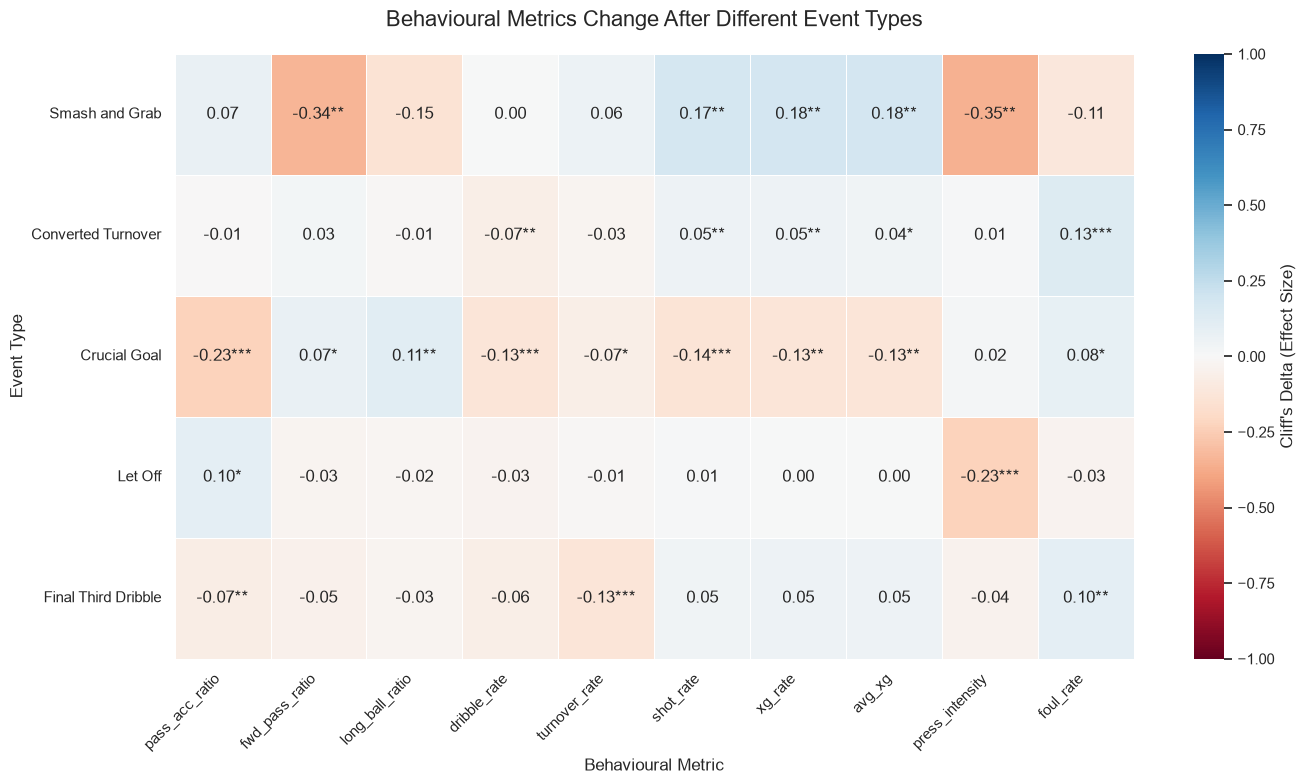

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cliff's delta to pivot for heatmap
heatmap_data = results_df.pivot(index='event_type', columns='metric', values='cliffs_delta')

# Pivot for p-values
pval_data = results_df.pivot(index='event_type', columns='metric', values='p_value_fdr')

heatmap_data = heatmap_data.reindex(index=event_order, columns=metric_order)
pval_data = pval_data.reindex(index=event_order, columns=metric_order)

annot_data = heatmap_data.copy().astype(str)

for row in heatmap_data.index:
    for col in heatmap_data.columns:
        c_delta = heatmap_data.loc[row, col]
        p_val = pval_data.loc[row, col]
            
        # Stars based on FDR-corrected p-value
        stars = ""
        if p_val < 0.001:
            stars = "***"
        elif p_val < 0.01:
            stars = "**"
        elif p_val < 0.05:
            stars = "*"
            
        # Annotation formatting: 2 decimal places + stars (e.g., "-0.32**")
        annot_data.loc[row, col] = f"{c_delta:.2f}{stars}"

# Drawing the heatmap
plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

ax = sns.heatmap(
    heatmap_data, 
    annot=annot_data,
    fmt="",
    cmap="RdBu",          # Red for negative, Blue for positive
    vmin=-1, vmax=1,      # Cliff's delta boundaries
    center=0,
    linewidths=.5,
    cbar_kws={'label': "Cliff's Delta (Effect Size)"}
)

# Formatting the plot
plt.title('Behavioural Metrics Change After Different Event Types', fontsize=16, pad=20)
plt.xlabel('Behavioural Metric', fontsize=12)
plt.ylabel('Event Type', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

if MODE == 'PDE':
    plt.savefig('output/pde/analysis/behavioural_change_heatmap_before_vs_after.png', dpi=300)
elif MODE == 'PFE':
    plt.savefig('output/pfe/analysis/behavioural_change_heatmap_before_vs_after.png', dpi=300)

plt.show()

In [6]:
from scipy.stats import wilcoxon, rankdata

metrics = [
    'pass_acc_ratio', 'fwd_pass_ratio', 'long_ball_ratio', 'xg_rate', 
    'shot_rate', 'avg_xg', 'dribble_rate', 'turnover_rate', 
    'foul_rate', 'press_intensity'
]

# Paired rank-biserial effect size for PDE post-values versus matched control means.
def paired_rank_biserial(differences):

    differences = np.asarray(differences, dtype=float)
    nonzero_differences = differences[~np.isclose(differences, 0)]
    if len(nonzero_differences) == 0:
        return 0.0

    ranks = rankdata(np.abs(nonzero_differences), method='average')
    positive_rank_sum = ranks[nonzero_differences > 0].sum()
    negative_rank_sum = ranks[nonzero_differences < 0].sum()
    return (positive_rank_sum - negative_rank_sum) / ranks.sum()

# Events with 3 control windows
control_counts = control_df['paired_event_id'].value_counts()
valid_event_ids = control_counts[control_counts == 3].index

# Only using Events that have exactly 3 controls
strict_event_df = event_df[event_df['event_id'].isin(valid_event_ids)].copy()
strict_control_df = control_df[control_df['paired_event_id'].isin(valid_event_ids)].copy()

secondary_test_results = []
event_types = strict_event_df['event_type'].unique()

for event in event_types:
    
    event_data = strict_event_df[strict_event_df['event_type'] == event]
    current_event_ids = event_data['event_id'].unique()
    
    # Searching for controls that match the current Event IDs
    matched_controls = strict_control_df[strict_control_df['paired_event_id'].isin(current_event_ids)]
    
    for metric in metrics:
        post_col = f'post_{metric}'
        control_col = f'post_{metric}'
        
        # Average the three controls so each PDE contributes one paired control observation.
        control_means = (
            matched_controls.groupby('paired_event_id', as_index=False)[control_col]
            .mean()
            .rename(columns={control_col: 'control_mean'})
        )
        comparison = (
            event_data[['event_id', post_col]]
            .merge(control_means, left_on='event_id', right_on='paired_event_id', how='inner')
            .dropna(subset=[post_col, 'control_mean'])
        )
        
        differences = (comparison[post_col] - comparison['control_mean']).to_numpy(dtype=float)
        differences = differences[np.isfinite(differences)]
        
        # Paired Wilcoxon signed-rank test at the PDE level.
        if len(differences) < 5 or np.all(np.isclose(differences, 0)):
            p_val = 1.0 if len(differences) >= 5 else np.nan
            effect_size = 0.0 if len(differences) >= 5 else np.nan
        else:
            stat, p_val = wilcoxon(differences, zero_method='wilcox', alternative='two-sided')
            effect_size = paired_rank_biserial(differences)
            
        secondary_test_results.append({
            'event_type': event,
            'metric': metric,
            'cliffs_delta': effect_size,
            'p_value_raw': p_val
        })

secondary_results_df = pd.DataFrame(secondary_test_results)

# FDR correction for secondary tests
reject, pvals_corrected, _, _ = multipletests(
    pvals=secondary_results_df['p_value_raw'],
    alpha=0.05,
    method='fdr_bh'
)

secondary_results_df['p_value_fdr'] = pvals_corrected
secondary_results_df['is_significant'] = reject

secondary_results_df.sort_values(by=['event_type', 'metric'], inplace=True)

display(secondary_results_df.head(10))

,event_type,metric,cliffs_delta,p_value_raw,p_value_fdr,is_significant
5,Converted Turnover,avg_xg,0.037872,2.267112e-01,3.778520e-01,False
6,Converted Turnover,dribble_rate,-0.063322,3.766057e-02,8.187080e-02,False
8,Converted Turnover,foul_rate,0.039818,1.955817e-01,3.372098e-01,False
1,Converted Turnover,fwd_pass_ratio,-0.079293,6.137349e-03,1.805103e-02,True
2,Converted Turnover,long_ball_ratio,-0.084792,3.365354e-03,1.121785e-02,True
0,Converted Turnover,pass_acc_ratio,0.104615,2.971966e-04,1.143064e-03,True
9,Converted Turnover,press_intensity,-0.164403,1.779952e-08,2.966587e-07,True
4,Converted Turnover,shot_rate,0.295706,2.958444e-20,1.479222e-18,True
7,Converted Turnover,turnover_rate,-0.021359,4.841888e-01,6.195178e-01,False
3,Converted Turnover,xg_rate,0.043213,1.677894e-01,2.996239e-01,False


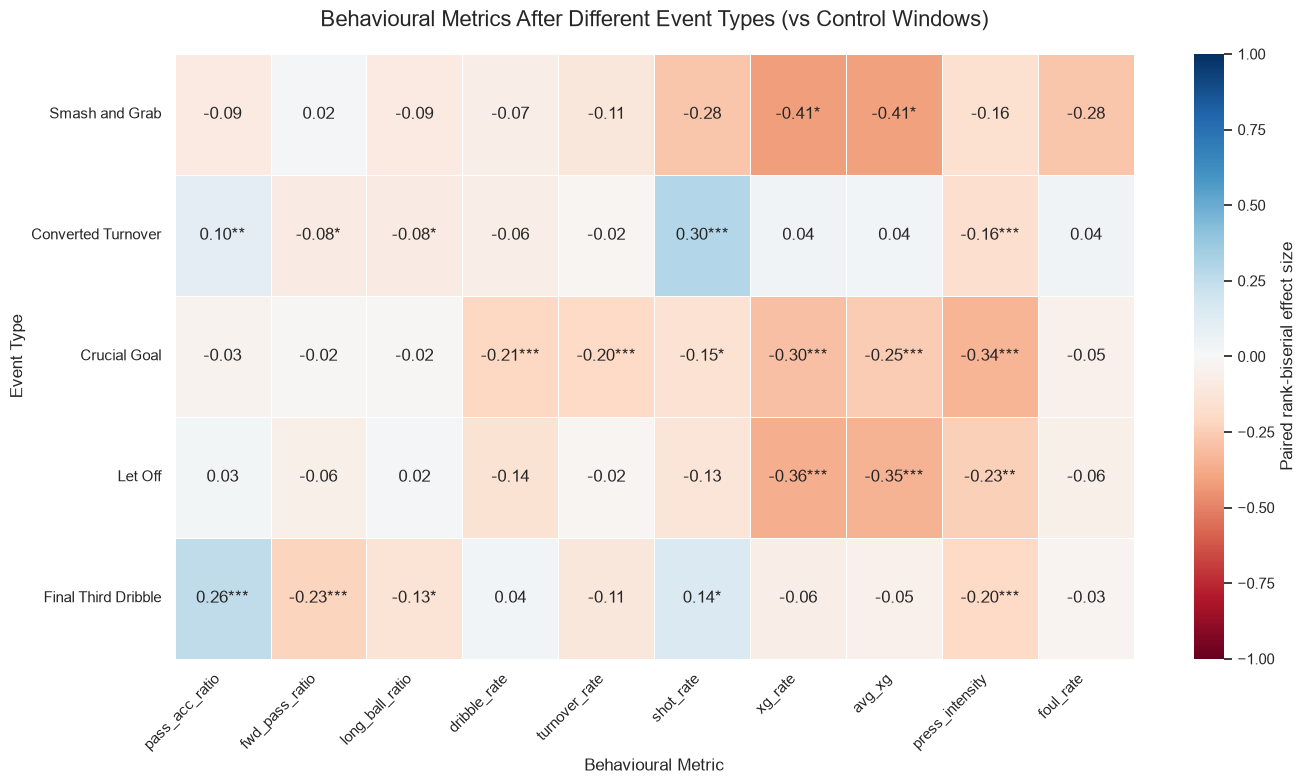

In [7]:
# Paired rank-biserial effect size to pivot for heatmap
heatmap_data = secondary_results_df.pivot(index='event_type', columns='metric', values='cliffs_delta')

# Pivot for p-values
pval_data = secondary_results_df.pivot(index='event_type', columns='metric', values='p_value_fdr')

heatmap_data = heatmap_data.reindex(index=event_order, columns=metric_order)
pval_data = pval_data.reindex(index=event_order, columns=metric_order)

annot_data = heatmap_data.copy().astype(str)

for row in heatmap_data.index:
    for col in heatmap_data.columns:
        c_delta = heatmap_data.loc[row, col]
        p_val = pval_data.loc[row, col]
            
        # Stars based on FDR-corrected p-value
        stars = ""
        if p_val < 0.001:
            stars = "***"
        elif p_val < 0.01:
            stars = "**"
        elif p_val < 0.05:
            stars = "*"
            
        # Annotation formatting: 2 decimal places + stars (e.g., "-0.32**")
        annot_data.loc[row, col] = f"{c_delta:.2f}{stars}"

# Drawing the heatmap
plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

ax = sns.heatmap(
    heatmap_data, 
    annot=annot_data,
    fmt="",
    cmap="RdBu",          # Red for negative, Blue for positive
    vmin=-1, vmax=1,      # Rank-biserial effect-size boundaries
    center=0,
    linewidths=.5,
    cbar_kws={'label': "Paired rank-biserial effect size"}
)

# Formatting the plot
plt.title('Behavioural Metrics After Different Event Types (vs Control Windows)', fontsize=16, pad=20)
plt.xlabel('Behavioural Metric', fontsize=12)
plt.ylabel('Event Type', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

if MODE == 'PDE':
    plt.savefig('output/pde/analysis/behavioural_change_heatmap_vs_control.png', dpi=300)
elif MODE == 'PFE':
    plt.savefig('output/pfe/analysis/behavioural_change_heatmap_vs_control.png', dpi=300)

plt.show()